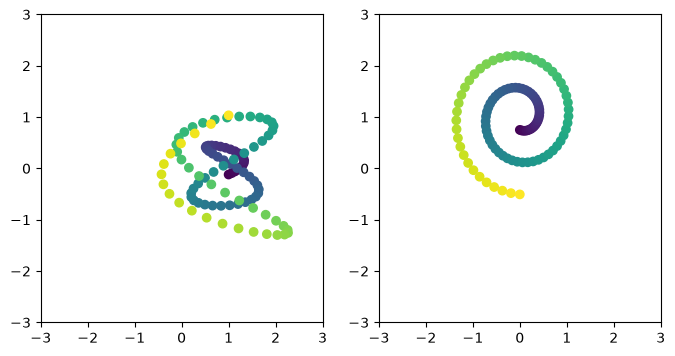

In [1]:
import numpy
import matplotlib
from matplotlib import pyplot as plt
import utils
from scipy.linalg import eigh

X,Y   = utils.getdata()
p1,p2 = utils.plotdata(X,Y)

For these two trajetories, that can be understood as two different modalities of the same data, I will determine under which projections they appear maximally correlated using the CCA.

The CCA problem in its original form consists of maximizing the cross-correlation objective:

$$J(w_x,w_y) =  w_x^\top C_{xy} w_y$$

subject to autocorrelation constraints $w_x^\top C_{xx} w_x = 1$ and $w_y^\top C_{yy} w_y = 1$. Using the method of Lagrange multipliers, this optimization problem can be reduced to finding the first eigenvector of the generalized eigenvalue problem:

$$
\begin{bmatrix}0 & C_{xy}\\C_{yx} & 0\end{bmatrix}
\begin{bmatrix}w_x\\w_y\end{bmatrix} =
\lambda
\begin{bmatrix}C_{xx} & 0\\0 & C_{yy}\end{bmatrix}
\begin{bmatrix}w_x\\w_y\end{bmatrix} 
$$

I first write a function that solves this generalized eigenvalue problem. The function I need to implement receives two matrices `X` and `Y` of size `d1` $\times$ `N` and  `d2` $\times$ `N` respectively. It should return two vectors of size `d1` and `d2` corresponding to the projections associated to the modalities `X` and `Y`.

In [8]:
def CCA(X,Y):
    d,N = X.shape
    Xc = X-X.mean(axis=1,keepdims=True)
    Yc = Y-Y.mean(axis=1,keepdims=True)
    Cxx = numpy.dot(Xc,Xc.T) / N
    Cxy = numpy.dot(Xc,Yc.T) / N
    Cyx = numpy.dot(Yc,Xc.T) / N
    Cyy = numpy.dot(Yc,Yc.T) / N
    S = numpy.block([
    [Cxx*0,Cxy],
    [Cyx,Cyy*0]
    ])
    D = numpy.block([
    [Cxx,Cxy*0],
    [Cyx*0,Cyy]
    ])
    eigvals,eigvecs = eigh(S, D)
    ind = numpy.argmax(eigvals)
    eigval = eigvals[ind]
    eigvec = eigvecs[:,ind]
    wx = eigvec[:d]
    wy = eigvec[d:]
    return wx,wy

The function can now be called with the dataset. The learned projection vectors $w_x$ and $w_y$ are plotted as red arrows.

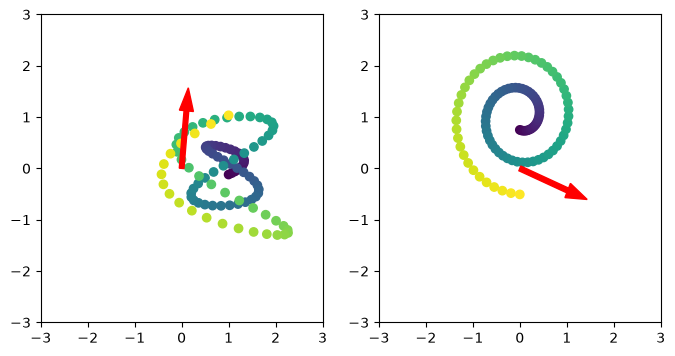

In [9]:
wx,wy = CCA(X,Y)

p1,p2 = utils.plotdata(X,Y)
p1.arrow(0,0,1*wx[0],1*wx[1],color='red',width=0.1)
p2.arrow(0,0,1*wy[0],1*wy[1],color='red',width=0.1)
plt.show()

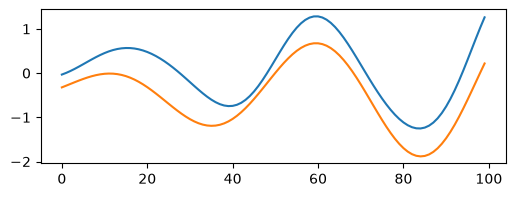

In [10]:
plt.figure(figsize=(6,2))
plt.plot(wx.dot(X))
plt.plot(wy.dot(Y))
plt.show()

Clearly, the data is correlated in the projected space.

## CCA for High Dimensions

I will now consider the case where the data is high dimensional (with `d` $\gg$ `N`). Such high-dimensionality occurs for example, when input data are images. I consider the scenario where sources emit spatially, and two (noisy) receivers measure the spatial field at different locations. I will like to identify the signal that is common to the two measured locations, e.g. a given source emitting at a given frequency.

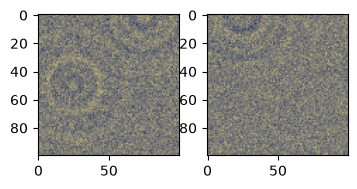

In [11]:
X,Y = utils.getHDdata()

utils.plotHDdata(X[:,0],Y[:,0])
plt.show()

Several sources can be perceived, however, there is a significant level of noise. Here again, we will use CCA to find subspaces where the two modalities are maximally correlated. In this example, because there are many more dimensions than there are data points, it is more advantageous to solve the alternate formulation of CCA in terms of the weightings $\alpha_x$ and $\alpha_y$. Your task is to implement the latter CCA solver. Like the original CCA solver, it receives two data matrices of size `d1` $\times$ `N` and `d2` $\times$ `N` respectively as input, and should return the associate CCA directions (two vectors of respective sizes `d1` and `d2`).

In [13]:
def CCA_HD(X,Y):
    N = X.shape[1]
    X = X - X.mean(axis=1,keepdims=True)
    Y = Y - Y.mean(axis=1,keepdims=True)
    Kxx = numpy.dot(X.T,X)
    Kyy = numpy.dot(Y.T,Y)
    Z = numpy.zeros([N,N])
    S = numpy.block([[Z,Kxx.dot(Kyy)/N],[Kyy.dot(Kxx)/N,Z]])
    D = numpy.block([[Kxx.dot(Kxx)/N+0.01*Kxx+0.01*numpy.eye(N),Z],[Z,Kyy.dot(Kyy)/
    N+0.01*Kyy+0.01*numpy.eye(N)]])
    eigvals,eigvecs = eigh(S, D)
    ind = numpy.argmax(eigvals)
    eigval = eigvals[ind]
    eigvec = eigvecs[:,ind]
    wx = numpy.dot(X,eigvec[:N])
    wy = numpy.dot(Y,eigvec[N:])
    return wx,wy

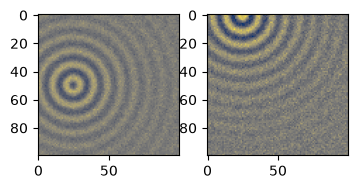

In [14]:
wx,wy = CCA_HD(X,Y)

utils.plotHDdata(wx,wy)
plt.show()

Here, one can clearly see a common factor that has been extracted between the two fields, specifically a point source emitting at a particular frequency. The sequence of image pairs can now be projected on these two filters:

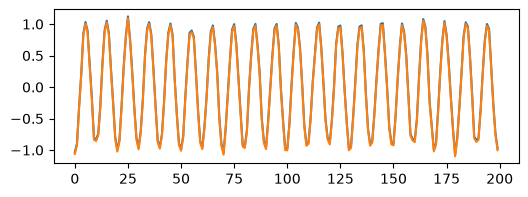

In [15]:
plt.figure(figsize=(6,2))
plt.plot(wx.dot(X))
plt.plot(wy.dot(Y))
plt.show()